<a href="https://colab.research.google.com/github/Beyzaece/Afiyet-Yolunda-Yemek-Teslim/blob/main/Another_copy_of_OCT2017_EfficientNetB6_B7_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os, zipfile, shutil
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB6, EfficientNetB7
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

import os


Drive Adresinden Dosya işlemler

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Zip dosyasından Çıkarma

In [ ]:
def unzip_clean(zip_path, extract_to):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        for member in zip_ref.namelist():
            filename = os.path.basename(member)
            if not filename:
                continue
            source = zip_ref.open(member)
            target_dir = os.path.join(extract_to, os.path.dirname(member).split('/')[-1])
            os.makedirs(target_dir, exist_ok=True)
            with open(os.path.join(target_dir, filename), "wb") as target:
                with source as src:
                    target.write(src.read())

In [ ]:
train_zip = '/content/drive/MyDrive/OCT2017/train.zip'
test_zip = '/content/drive/MyDrive/OCT2017/test.zip'
unzip_clean(train_zip, '/content/train')
unzip_clean(test_zip, '/content/test')

train_path = '/content/train'
test_path = '/content/test'

Train/Test Görüntü Veri Üretimi ve Ön işleme (B6)

In [ ]:
train_datagen_b6 = ImageDataGenerator(rescale=1./255, zoom_range=0.3, horizontal_flip=True)
test_datagen_b6 = ImageDataGenerator(rescale=1./255)

train_gen_b6 = train_datagen_b6.flow_from_directory(
    train_path,
    target_size=(528, 528),
    batch_size=8,
    class_mode='categorical'
)

test_gen_b6 = test_datagen_b6.flow_from_directory(
    test_path,
    target_size=(528, 528),
    batch_size=8,
    class_mode='categorical'
)

Found 83484 images belonging to 4 classes.
Found 1000 images belonging to 4 classes.


EfficientNetB6 Görüntü Sınıflandırma Modeli

In [ ]:



base_model_b6 = EfficientNetB6(weights='imagenet', include_top=False, input_shape=(528, 528, 3))
x = GlobalAveragePooling2D()(base_model_b6.output)
x = Dropout(0.5)(x)
output = Dense(train_gen_b6.num_classes, activation='softmax')(x)
model_b6 = Model(inputs=base_model_b6.input, outputs=output)
model_b6.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
model_b6.summary()




165234480/165234480 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 528, 528,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 528, 528,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 528, 528,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 528, 528,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 529, 529,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 264, 264,  │      1,512 │ stem_conv_pad[0]… │
│                     │ 56)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 264, 264,  │        224 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 56)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 264, 264,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 56)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 264, 264,  │        504 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 56)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 264, 264,  │        224 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 56)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 264, 264,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 56)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 56)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 56)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 14)  │        798 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 56)  │        840 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 264, 264,  │          0 │ block1a_activati… │
│ (Multiply)          │ 56)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 264, 264,  │      1,792 │ block1a_se_excit

 Total params: 40,969,363 (156.29 MB)

 Trainable params: 40,744,924 (155.43 MB)

 Non-trainable params: 224,439 (876.72 KB)

En İyi Modeli Kaydetme ve Erken Durdurma


In [ ]:

checkpoint_b6 = ModelCheckpoint(
    filepath='/content/drive/MyDrive/OCT2017/best_model_b6.h5',
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)
early_stop_b6 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

history_b6 = model_b6.fit(
    train_gen_b6,
    validation_data=test_gen_b6,
    epochs=30,
    verbose=1,
    callbacks=[checkpoint_b6, early_stop_b6]
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.9223 - loss: 0.2274
Epoch 1: val_accuracy improved from -inf to 0.29900, saving model to /content/drive/MyDrive/OCT2017/best_model_b6.h5


10436/10436 ━━━━━━━━━━━━━━━━━━━━ 4878s 448ms/step - accuracy: 0.9223 - loss: 0.2274 - val_accuracy: 0.2990 - val_loss: 1.4831
Epoch 2/30
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.9657 - loss: 0.1046
Epoch 2: val_accuracy did not improve from 0.29900
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 4535s 435ms/step - accuracy: 0.9657 - loss: 0.1046 - val_accuracy: 0.2500 - val_loss: 1.7585
Epoch 3/30
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.9723 - loss: 0.0818
Epoch 3: val_accuracy did not improve from 0.29900
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 4529s 434ms/step - accuracy: 0.9723 - loss: 0.0818 - val_accuracy: 0.2500 - val_loss: 1.8732
Epoch 4/30
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.9772 - loss: 0.0673
Epoch 4: val_accuracy improved from 0.29900 to 0.97800, saving model to /content/drive/MyDrive/OCT2017/best_model_b6.h5


10436/10436 ━━━━━━━━━━━━━━━━━━━━ 4546s 436ms/step - accuracy: 0.9772 - loss: 0.0673 - val_accuracy: 0.9780 - val_loss: 0.0744
Epoch 5/30
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.9788 - loss: 0.0600
Epoch 5: val_accuracy did not improve from 0.97800
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 4562s 437ms/step - accuracy: 0.9788 - loss: 0.0600 - val_accuracy: 0.9680 - val_loss: 0.0876
Epoch 6/30
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.9818 - loss: 0.0531
Epoch 6: val_accuracy did not improve from 0.97800
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 4573s 438ms/step - accuracy: 0.9818 - loss: 0.0531 - val_accuracy: 0.4900 - val_loss: 1.0975
Epoch 7/30
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.9828 - loss: 0.0488
Epoch 7: val_accuracy did not improve from 0.97800
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 4555s 436ms/step - accuracy: 0.9828 - loss: 0.0488 - val_accuracy: 0.2500 - val_loss: 1.7430
Epoch 8/30
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accurac

10436/10436 ━━━━━━━━━━━━━━━━━━━━ 4553s 436ms/step - accuracy: 0.9839 - loss: 0.0446 - val_accuracy: 0.9910 - val_loss: 0.0298
Epoch 9/30
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.9853 - loss: 0.0436
Epoch 9: val_accuracy did not improve from 0.99100
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 4519s 433ms/step - accuracy: 0.9853 - loss: 0.0436 - val_accuracy: 0.8800 - val_loss: 0.3310
Epoch 10/30
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.9871 - loss: 0.0362
Epoch 10: val_accuracy did not improve from 0.99100
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 4518s 433ms/step - accuracy: 0.9871 - loss: 0.0362 - val_accuracy: 0.5120 - val_loss: 1.0927
Epoch 11/30
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.9873 - loss: 0.0363
Epoch 11: val_accuracy did not improve from 0.99100
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 4548s 436ms/step - accuracy: 0.9873 - loss: 0.0363 - val_accuracy: 0.9870 - val_loss: 0.0417
Epoch 12/30
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - ac

10436/10436 ━━━━━━━━━━━━━━━━━━━━ 4576s 438ms/step - accuracy: 0.9880 - loss: 0.0341 - val_accuracy: 0.9960 - val_loss: 0.0228
Epoch 13/30
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.9881 - loss: 0.0326
Epoch 13: val_accuracy did not improve from 0.99600
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 4522s 433ms/step - accuracy: 0.9881 - loss: 0.0326 - val_accuracy: 0.4620 - val_loss: 1.3194
Epoch 14/30
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.9892 - loss: 0.0296
Epoch 14: val_accuracy did not improve from 0.99600
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 4542s 435ms/step - accuracy: 0.9892 - loss: 0.0296 - val_accuracy: 0.9070 - val_loss: 0.3471
Epoch 15/30
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.9897 - loss: 0.0285
Epoch 15: val_accuracy improved from 0.99600 to 0.99700, saving model to /content/drive/MyDrive/OCT2017/best_model_b6.h5


10436/10436 ━━━━━━━━━━━━━━━━━━━━ 4558s 437ms/step - accuracy: 0.9897 - loss: 0.0285 - val_accuracy: 0.9970 - val_loss: 0.0104
Epoch 16/30
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.9897 - loss: 0.0295
Epoch 16: val_accuracy did not improve from 0.99700
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 4534s 434ms/step - accuracy: 0.9897 - loss: 0.0295 - val_accuracy: 0.9940 - val_loss: 0.0241
Epoch 17/30
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.9906 - loss: 0.0267
Epoch 17: val_accuracy did not improve from 0.99700
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 4567s 438ms/step - accuracy: 0.9906 - loss: 0.0267 - val_accuracy: 0.9760 - val_loss: 0.0606
Epoch 18/30
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.9912 - loss: 0.0244
Epoch 18: val_accuracy did not improve from 0.99700
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 4584s 439ms/step - accuracy: 0.9912 - loss: 0.0244 - val_accuracy: 0.9380 - val_loss: 0.2019
Epoch 19/30
 6688/10436 ━━━━━━━━━━━━━━━━━━━━ 27:08 435ms/step

EfficientNetB7 ile Görüntü Sınıflandırma

In [ ]:
train_datagen_b7 = ImageDataGenerator(rescale=1./255, zoom_range=0.3, horizontal_flip=True)
test_datagen_b7 = ImageDataGenerator(rescale=1./255)

train_gen_b7 = train_datagen_b7.flow_from_directory(
    train_path,
    target_size=(600, 600),
    batch_size=8,
    class_mode='categorical'
)

test_gen_b7 = test_datagen_b7.flow_from_directory(
    test_path,
    target_size=(600, 600),
    batch_size=8,
    class_mode='categorical'
)

Found 83484 images belonging to 4 classes.
Found 1000 images belonging to 4 classes.


EfficientNetB7 ile Görüntü Sınıflandırma Modeli

In [ ]:
base_model_b7 = EfficientNetB7(weights='imagenet', include_top=False, input_shape=(600, 600, 3))
x = GlobalAveragePooling2D()(base_model_b7.output)
x = Dropout(0.5)(x)
output = Dense(train_gen_b7.num_classes, activation='softmax')(x)
model_b7 = Model(inputs=base_model_b7.input, outputs=output)
model_b7.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
model_b7.summary()

258076736/258076736 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 600, 600,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 600, 600,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 600, 600,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 600, 600,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 601, 601,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 300, 300,  │      1,728 │ stem_conv_pad[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 300, 300,  │        256 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 300, 300,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 300, 300,  │        576 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 300, 300,  │        256 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 300, 300,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 64)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 64)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 16)  │      1,040 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 64)  │      1,088 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 300, 300,  │          0 │ block1a_activati… │
│ (Multiply)          │ 64)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 300, 300,  │      2,048 │ block1a_se_excit

 Total params: 64,107,931 (244.55 MB)

 Trainable params: 63,797,204 (243.37 MB)

 Non-trainable params: 310,727 (1.19 MB)

EfficientNet B7 En iyi Modeli Kaydetme ve Erken Durdurma

In [ ]:
checkpoint_b7 = ModelCheckpoint(
    filepath='/content/drive/MyDrive/OCT2017/best_model_b7.h5',
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)
early_stop_b7 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

history_b7 = model_b7.fit(
    train_gen_b7,
    validation_data=test_gen_b7,
    epochs=30,
    verbose=1,
    callbacks=[checkpoint_b7, early_stop_b7]
)

Epoch 1/30
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 0s 587ms/step - accuracy: 0.9282 - loss: 0.2143
Epoch 1: val_accuracy improved from -inf to 0.87100, saving model to /content/drive/MyDrive/OCT2017/best_model_b7.h5


10436/10436 ━━━━━━━━━━━━━━━━━━━━ 6407s 590ms/step - accuracy: 0.9282 - loss: 0.2143 - val_accuracy: 0.8710 - val_loss: 0.3029
Epoch 2/30
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 0s 573ms/step - accuracy: 0.9653 - loss: 0.1004
Epoch 2: val_accuracy improved from 0.87100 to 0.88200, saving model to /content/drive/MyDrive/OCT2017/best_model_b7.h5


10436/10436 ━━━━━━━━━━━━━━━━━━━━ 5999s 575ms/step - accuracy: 0.9653 - loss: 0.1004 - val_accuracy: 0.8820 - val_loss: 0.3022
Epoch 3/30
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 0s 566ms/step - accuracy: 0.9720 - loss: 0.0818
Epoch 3: val_accuracy did not improve from 0.88200
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 5916s 567ms/step - accuracy: 0.9720 - loss: 0.0818 - val_accuracy: 0.2510 - val_loss: 1.6547
Epoch 4/30
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 0s 574ms/step - accuracy: 0.9763 - loss: 0.0692
Epoch 4: val_accuracy improved from 0.88200 to 0.98600, saving model to /content/drive/MyDrive/OCT2017/best_model_b7.h5


10436/10436 ━━━━━━━━━━━━━━━━━━━━ 6012s 576ms/step - accuracy: 0.9763 - loss: 0.0692 - val_accuracy: 0.9860 - val_loss: 0.0488
Epoch 5/30
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 0s 574ms/step - accuracy: 0.9796 - loss: 0.0609
Epoch 5: val_accuracy did not improve from 0.98600
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 5997s 575ms/step - accuracy: 0.9796 - loss: 0.0609 - val_accuracy: 0.8970 - val_loss: 0.2605
Epoch 6/30
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 0s 574ms/step - accuracy: 0.9799 - loss: 0.0579
Epoch 6: val_accuracy did not improve from 0.98600
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 5999s 575ms/step - accuracy: 0.9799 - loss: 0.0579 - val_accuracy: 0.9650 - val_loss: 0.0979
Epoch 7/30
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 0s 575ms/step - accuracy: 0.9821 - loss: 0.0514
Epoch 7: val_accuracy did not improve from 0.98600
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 6006s 575ms/step - accuracy: 0.9821 - loss: 0.0514 - val_accuracy: 0.6340 - val_loss: 0.9803
Epoch 8/30
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 0s 570ms/step - accurac

10436/10436 ━━━━━━━━━━━━━━━━━━━━ 6035s 578ms/step - accuracy: 0.9847 - loss: 0.0430 - val_accuracy: 0.9890 - val_loss: 0.0322
Epoch 10/30
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 0s 569ms/step - accuracy: 0.9858 - loss: 0.0406
Epoch 10: val_accuracy improved from 0.98900 to 0.99600, saving model to /content/drive/MyDrive/OCT2017/best_model_b7.h5


10436/10436 ━━━━━━━━━━━━━━━━━━━━ 5963s 571ms/step - accuracy: 0.9858 - loss: 0.0406 - val_accuracy: 0.9960 - val_loss: 0.0143
Epoch 11/30
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 0s 571ms/step - accuracy: 0.9871 - loss: 0.0377
Epoch 11: val_accuracy improved from 0.99600 to 0.99800, saving model to /content/drive/MyDrive/OCT2017/best_model_b7.h5


10436/10436 ━━━━━━━━━━━━━━━━━━━━ 5982s 573ms/step - accuracy: 0.9871 - loss: 0.0377 - val_accuracy: 0.9980 - val_loss: 0.0110
Epoch 12/30
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 0s 567ms/step - accuracy: 0.9882 - loss: 0.0345
Epoch 12: val_accuracy did not improve from 0.99800
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 5928s 568ms/step - accuracy: 0.9882 - loss: 0.0345 - val_accuracy: 0.9960 - val_loss: 0.0135
Epoch 13/30
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 0s 570ms/step - accuracy: 0.9879 - loss: 0.0352
Epoch 13: val_accuracy did not improve from 0.99800
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 5955s 571ms/step - accuracy: 0.9879 - loss: 0.0352 - val_accuracy: 0.3270 - val_loss: 4.0258
Epoch 14/30
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 0s 572ms/step - accuracy: 0.9896 - loss: 0.0306
Epoch 14: val_accuracy did not improve from 0.99800
10436/10436 ━━━━━━━━━━━━━━━━━━━━ 5974s 572ms/step - accuracy: 0.9896 - loss: 0.0306 - val_accuracy: 0.7990 - val_loss: 0.4811
Epoch 15/30
 1779/10436 ━━━━━━━━━━━━━━━━━━━━ 1:22:25 571ms/st

In [ ]:
model_b7 = load_model('/content/drive/MyDrive/OCT2017/best_model_b7.h5')


Örnek

1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step


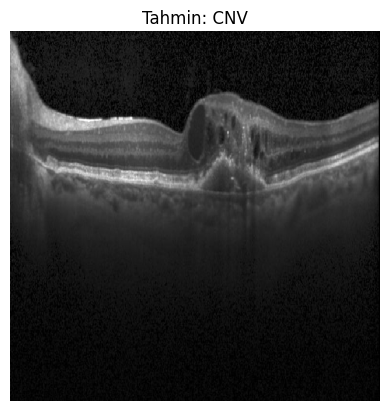

Sınıf olasılıkları: [[9.7718143e-01 2.1371763e-02 6.6440937e-04 7.8239839e-04]]
Tahmin edilen sınıf: CNV


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image


img_path = next(iter(uploaded))


img = image.load_img(img_path, target_size=(600, 600))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)


prediction = model_b7.predict(img_array)
class_names = ['CNV', 'DME', 'DRUSEN', 'NORMAL']
predicted_class = class_names[np.argmax(prediction)]


plt.imshow(img)
plt.title(f'Tahmin: {predicted_class}')
plt.axis('off')
plt.show()

print("Sınıf olasılıkları:", prediction)
print("Tahmin edilen sınıf:", predicted_class)


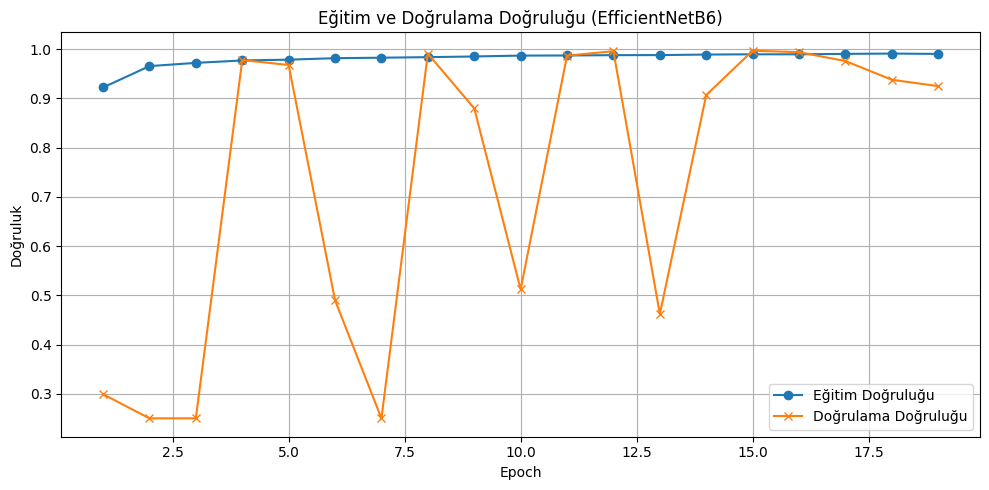

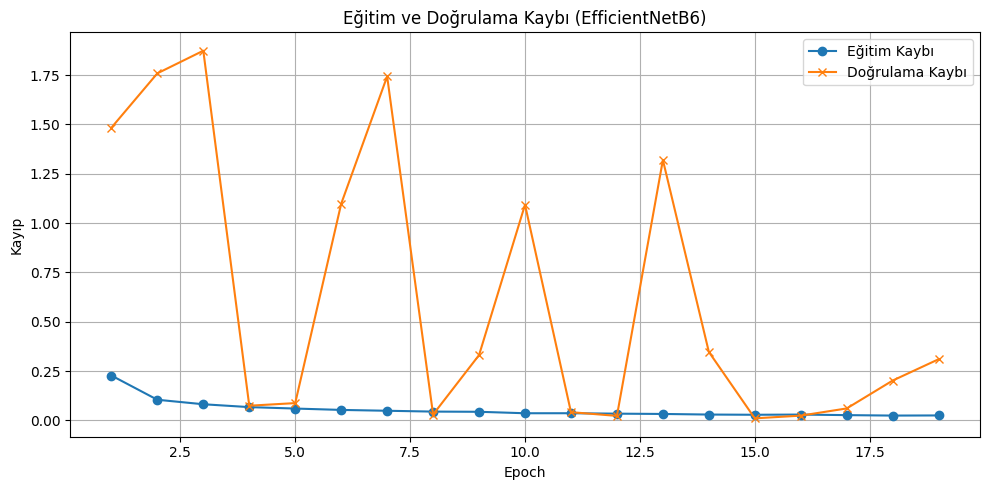

In [ ]:

import matplotlib.pyplot as plt

# Epoch bilgisi
epochs = list(range(1, 19 + 1))  # 1-19 arası

# Veriler (19 eleman)
train_accuracy = [0.9223, 0.9657, 0.9723, 0.9772, 0.9788, 0.9818, 0.9828, 0.9839, 0.9853, 0.9871, 0.9873, 0.9880, 0.9881, 0.9892, 0.9897, 0.9897, 0.9906, 0.9912, 0.9905]
val_accuracy   = [0.2990, 0.2500, 0.2500, 0.9780, 0.9680, 0.4900, 0.2500, 0.9910, 0.8800, 0.5120, 0.9870, 0.9960, 0.4620, 0.9070, 0.9970, 0.9940, 0.9760, 0.9380, 0.9250]

train_loss = [0.2274, 0.1046, 0.0818, 0.0673, 0.0600, 0.0531, 0.0488, 0.0446, 0.0436, 0.0362, 0.0363, 0.0341, 0.0326, 0.0296, 0.0285, 0.0295, 0.0267, 0.0244, 0.0251]
val_loss   = [1.4831, 1.7585, 1.8732, 0.0744, 0.0876, 1.0975, 1.7430, 0.0298, 0.3310, 1.0927, 0.0417, 0.0228, 1.3194, 0.3471, 0.0104, 0.0241, 0.0606, 0.2019, 0.3100]

# 🔷 Doğruluk Grafiği
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_accuracy, label='Eğitim Doğruluğu', marker='o')
plt.plot(epochs, val_accuracy, label='Doğrulama Doğruluğu', marker='x')
plt.xlabel('Epoch')
plt.ylabel('Doğruluk')
plt.title('Eğitim ve Doğrulama Doğruluğu (EfficientNetB6)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/efficientnet_b6_accuracy.png')
plt.show()

# 🔶 Kayıp Grafiği
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_loss, label='Eğitim Kaybı', marker='o')
plt.plot(epochs, val_loss, label='Doğrulama Kaybı', marker='x')
plt.xlabel('Epoch')
plt.ylabel('Kayıp')
plt.title('Eğitim ve Doğrulama Kaybı (EfficientNetB6)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/efficientnet_b6_loss.png')
plt.show()


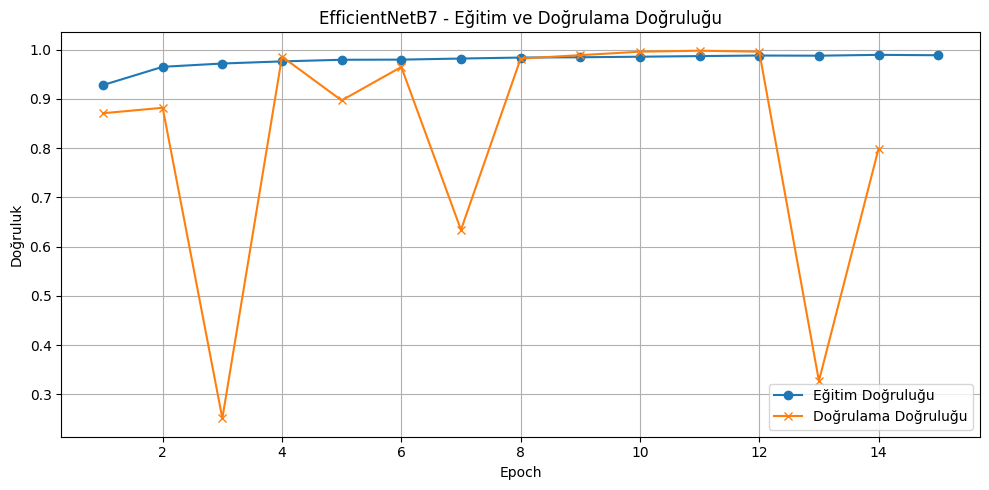

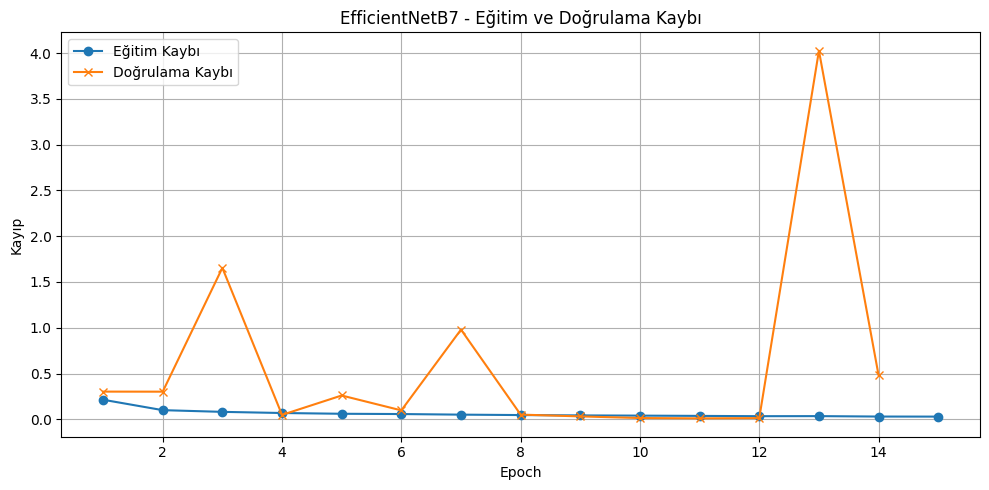

In [ ]:
import matplotlib.pyplot as plt

# Epoch listesi (1'den 15'e kadar çünkü 15. epoch yarım kaldı)
epochs = list(range(1, 16))

train_accuracy = [0.9282, 0.9653, 0.9720, 0.9763, 0.9796, 0.9799, 0.9821, 0.9841, 0.9847, 0.9858, 0.9871, 0.9882, 0.9879, 0.9896, 0.9888]
train_loss = [0.2143, 0.1004, 0.0818, 0.0692, 0.0609, 0.0579, 0.0514, 0.0468, 0.0430, 0.0406, 0.0377, 0.0345, 0.0352, 0.0306, 0.0299]

val_accuracy = [0.8710, 0.8820, 0.2510, 0.9860, 0.8970, 0.9650, 0.6340, 0.9820, 0.9890, 0.9960, 0.9980, 0.9960, 0.3270, 0.7990, None]
val_loss = [0.3029, 0.3022, 1.6547, 0.0488, 0.2605, 0.0979, 0.9803, 0.0518, 0.0322, 0.0143, 0.0110, 0.0135, 4.0258, 0.4811, None]

# 15. epoch yarım, None olan verileri temizleyelim
valid_epochs = [i for i, val in enumerate(val_accuracy) if val is not None]

epochs_valid = [epochs[i] for i in valid_epochs]
val_accuracy_clean = [val_accuracy[i] for i in valid_epochs]
val_loss_clean = [val_loss[i] for i in valid_epochs]

# ✅ Accuracy Grafiği
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_accuracy, label='Eğitim Doğruluğu', marker='o')
plt.plot(epochs_valid, val_accuracy_clean, label='Doğrulama Doğruluğu', marker='x')
plt.xlabel('Epoch')
plt.ylabel('Doğruluk')
plt.title('EfficientNetB7 - Eğitim ve Doğrulama Doğruluğu')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/efficientnet_b7_accuracy.png')
plt.show()

# ✅ Loss Grafiği
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_loss, label='Eğitim Kaybı', marker='o')
plt.plot(epochs_valid, val_loss_clean, label='Doğrulama Kaybı', marker='x')
plt.xlabel('Epoch')
plt.ylabel('Kayıp')
plt.title('EfficientNetB7 - Eğitim ve Doğrulama Kaybı')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/efficientnet_b7_loss.png')
plt.show()


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
test_path = "/content/test"

test_datagen = ImageDataGenerator(rescale=1./255)
test_gen = test_datagen.flow_from_directory(
    test_path,
    target_size=(600, 600),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)


Found 1000 images belonging to 4 classes.


In [ ]:
model = load_model('/content/drive/MyDrive/OCT2017/best_model_b7.h5')


pred_probs = model.predict(test_gen)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = test_gen.classes
class_labels = list(test_gen.class_indices.keys())


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


32/32 ━━━━━━━━━━━━━━━━━━━━ 89s 774ms/step


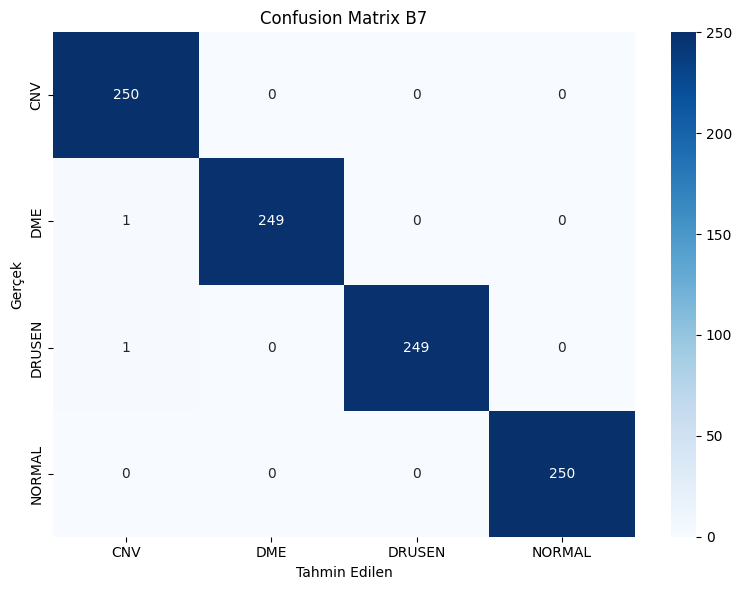

Sınıflandırma Raporu:
              precision    recall  f1-score   support

         CNV       0.99      1.00      1.00       250
         DME       1.00      1.00      1.00       250
      DRUSEN       1.00      1.00      1.00       250
      NORMAL       1.00      1.00      1.00       250

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [ ]:
# Confusion matrix hesapla
cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix B7")
plt.xlabel("Tahmin Edilen")
plt.ylabel("Gerçek")
plt.tight_layout()
plt.savefig('/content/confusion_matrix_b7.png')
plt.show()

# Sınıflandırma Raporu
print("Sınıflandırma Raporu:")
print(classification_report(true_classes, pred_classes, target_names=class_labels))


Found 1000 images belonging to 4 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


32/32 ━━━━━━━━━━━━━━━━━━━━ 75s 776ms/step


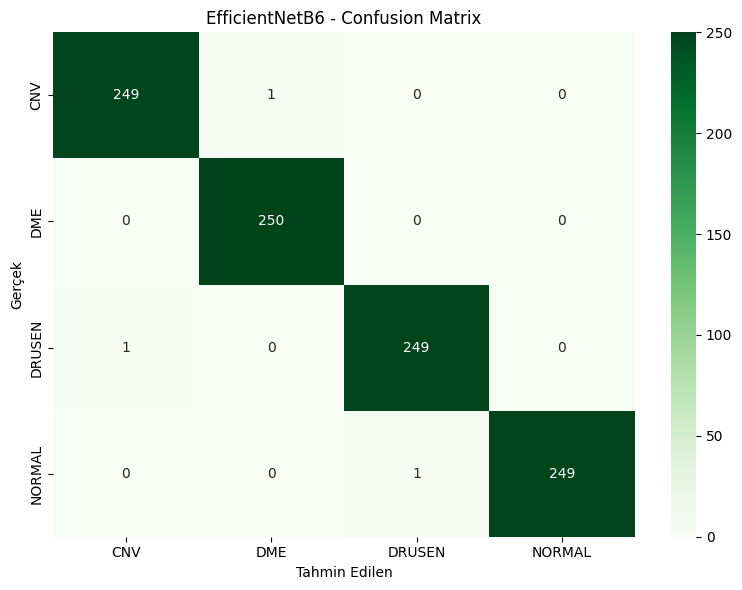

EfficientNetB6 - Sınıflandırma Raporu:
              precision    recall  f1-score   support

         CNV       1.00      1.00      1.00       250
         DME       1.00      1.00      1.00       250
      DRUSEN       1.00      1.00      1.00       250
      NORMAL       1.00      1.00      1.00       250

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [ ]:
test_path = "/content/test"

test_datagen = ImageDataGenerator(rescale=1./255)
test_gen_b6 = test_datagen.flow_from_directory(
    test_path,
    target_size=(528, 528),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)
model_b6 = load_model('/content/drive/MyDrive/OCT2017/best_model_b6.h5')

# Tahmin yap
pred_probs_b6 = model_b6.predict(test_gen_b6)
pred_classes_b6 = np.argmax(pred_probs_b6, axis=1)
true_classes_b6 = test_gen_b6.classes
class_labels_b6 = list(test_gen_b6.class_indices.keys())
cm_b6 = confusion_matrix(true_classes_b6, pred_classes_b6)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_b6, annot=True, fmt="d", cmap="Greens", xticklabels=class_labels_b6, yticklabels=class_labels_b6)
plt.title("EfficientNetB6 - Confusion Matrix")
plt.xlabel("Tahmin Edilen")
plt.ylabel("Gerçek")
plt.tight_layout()
plt.savefig('/content/confusion_matrix_b6.png')
plt.show()

print("EfficientNetB6 - Sınıflandırma Raporu:")
print(classification_report(true_classes_b6, pred_classes_b6, target_names=class_labels_b6))

